# Recommendation System Assignment — Anime Recommendation using Cosine Similarity

## Objective
The objective of this assignment is to implement a recommendation system using **cosine similarity** on an Anime dataset.

Dataset used: `anime.csv`

The dataset contains:

- `anime_id`: Unique ID of anime
- `name`: Anime title
- `genre`: Anime genre
- `type`: Broadcast type such as TV, Movie, OVA, etc.
- `episodes`: Number of episodes
- `rating`: Average rating
- `members`: Number of community members

This notebook includes:

1. Data loading  
2. Data preprocessing  
3. Missing value handling  
4. Dataset exploration  
5. Feature extraction  
6. Encoding categorical variables  
7. Normalization of numerical variables  
8. Cosine similarity calculation  
9. Recommendation function  
10. Threshold experiments  
11. Train-test split style evaluation  
12. Precision, recall, and F1-score  
13. Interview questions and answers  
14. Final conclusion

## 1. Install Required Libraries

In [3]:
# Run this cell only if libraries are missing
# !pip install pandas numpy matplotlib seaborn scikit-learn

## 2. Import Required Libraries

In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and similarity libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

In [5]:
anime_df = pd.read_csv("anime.csv")

print("Dataset Shape:", anime_df.shape)
display(anime_df.head())

Dataset Shape: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## 4. Dataset Information

In [6]:
print("Dataset Information:")
anime_df.info()

print("\nColumn Names:")
print(anime_df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB

Column Names:
['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']


## 5. Missing Values and Duplicate Check

In [7]:
print("Missing Values:")
print(anime_df.isnull().sum())

print("\nDuplicate Rows:", anime_df.duplicated().sum())

print("\nDuplicate Anime Names:", anime_df["name"].duplicated().sum())

Missing Values:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Duplicate Rows: 0

Duplicate Anime Names: 2


## 6. Handle Missing Values

Best practices used:

- Missing `genre` values are replaced with `"Unknown"`.
- Missing `type` values are replaced with mode.
- Missing `rating` values are replaced with median.
- `episodes` may contain `"Unknown"`, so it is converted to numeric and missing values are filled using median.

In [8]:
df = anime_df.copy()

# Fill genre
df["genre"] = df["genre"].fillna("Unknown")

# Fill type with mode
df["type"] = df["type"].fillna(df["type"].mode()[0])

# Convert episodes to numeric
df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")
df["episodes"] = df["episodes"].fillna(df["episodes"].median())

# Fill rating with median
df["rating"] = df["rating"].fillna(df["rating"].median())

# Fill members if missing
df["members"] = df["members"].fillna(df["members"].median())

# Remove duplicate anime names
df = df.drop_duplicates(subset=["name"]).reset_index(drop=True)

print("Missing values after handling:")
print(df.isnull().sum())

print("\nCleaned Dataset Shape:", df.shape)
display(df.head())

Missing values after handling:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

Cleaned Dataset Shape: (12292, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


# Exploratory Data Analysis

## 7. Summary Statistics

In [9]:
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))

,anime_id,episodes,rating,members
count,12292.000000,12292.000000,12292.000000,1.229200e+04
mean,14055.363082,12.097218,6.475792,1.807426e+04
std,11454.016570,46.247607,1.017129,5.482466e+04
min,1.000000,1.000000,1.670000,5.000000e+00
25%,3483.750000,1.000000,5.900000,2.257500e+02
50%,10259.500000,2.000000,6.570000,1.551000e+03
75%,24791.500000,12.000000,7.170000,9.441000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


Categorical Summary:


,name,genre,type
count,12292,12292,12292
unique,12292,3265,6
top,Yasuji no Pornorama: Yacchimae!!,Hentai,TV
freq,1,823,3812


## 8. Anime Type Distribution

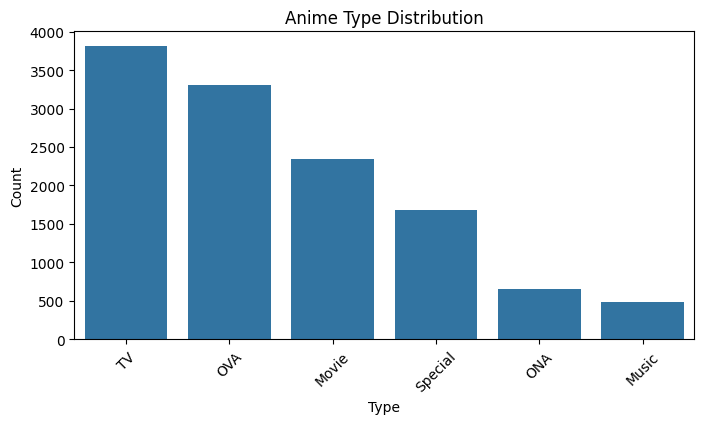

type
TV         3812
OVA        3311
Movie      2346
Special    1676
ONA         659
Music       488
Name: count, dtype: int64


In [10]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Anime Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print(df["type"].value_counts())

## 9. Rating Distribution

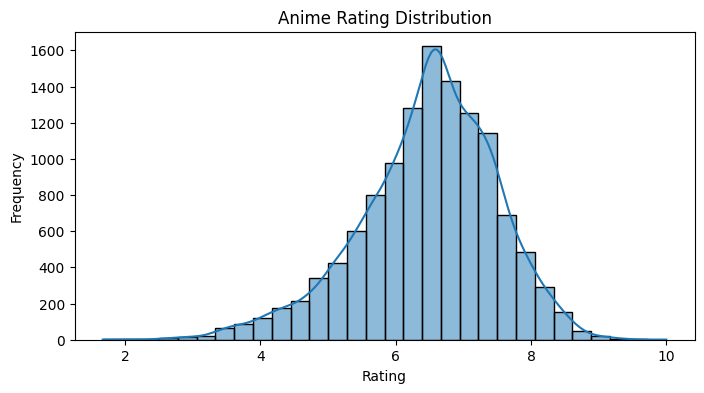

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df["rating"], kde=True, bins=30)
plt.title("Anime Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

## 10. Members Distribution

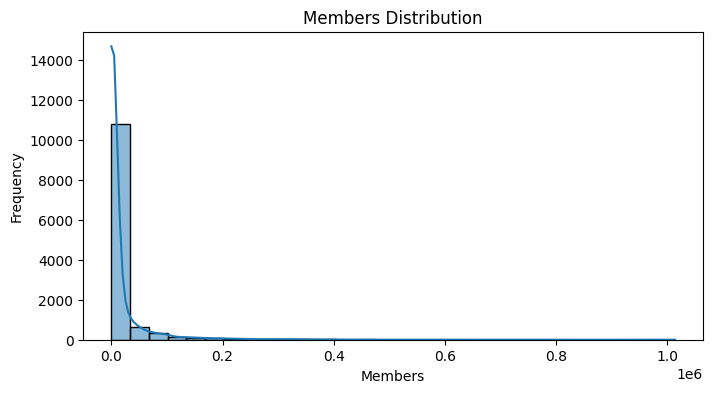

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df["members"], kde=True, bins=30)
plt.title("Members Distribution")
plt.xlabel("Members")
plt.ylabel("Frequency")
plt.show()

## 11. Episodes Distribution

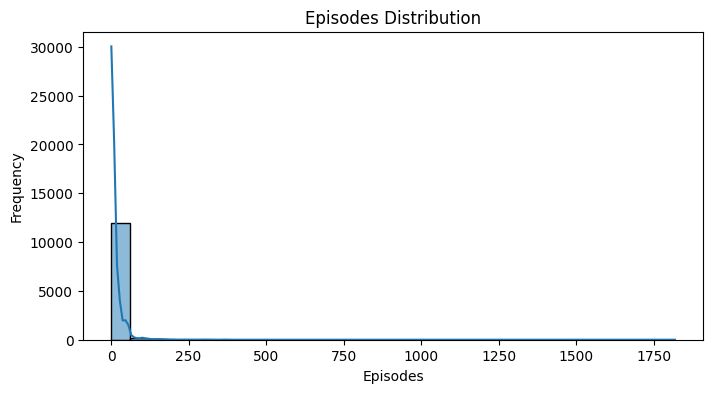

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df["episodes"], kde=True, bins=30)
plt.title("Episodes Distribution")
plt.xlabel("Episodes")
plt.ylabel("Frequency")
plt.show()

## 12. Top 10 Anime by Rating

,name,genre,type,episodes,rating,members
10462,Taka no Tsume 8: Yoshida-kun no X-Files,"Comedy, Parody",Movie,1.0,10.00,13
10398,Spoon-hime no Swing Kitchen,"Adventure, Kids",TV,2.0,9.60,47
9595,Mogura no Motoro,Slice of Life,Movie,1.0,9.50,62
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
9078,Kahei no Umi,Historical,Movie,1.0,9.33,44
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
10784,Yakusoku: Africa Mizu to Midori,"Drama, Kids",OVA,1.0,9.25,53
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


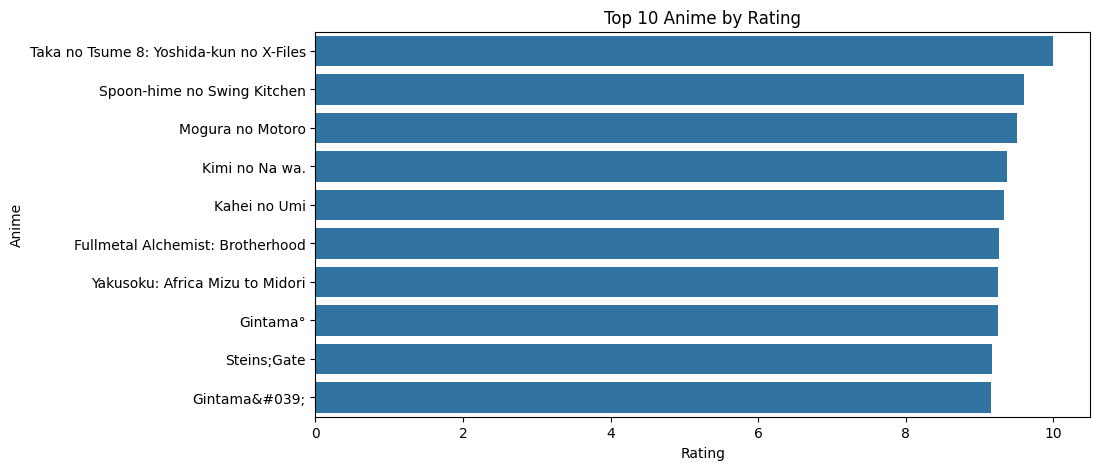

In [14]:
top_rating = df.sort_values(by="rating", ascending=False).head(10)

display(top_rating[["name", "genre", "type", "episodes", "rating", "members"]])

plt.figure(figsize=(10,5))
sns.barplot(data=top_rating, x="rating", y="name")
plt.title("Top 10 Anime by Rating")
plt.xlabel("Rating")
plt.ylabel("Anime")
plt.show()

## 13. Top 10 Anime by Members

,name,genre,type,episodes,rating,members
40,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37.0,8.71,1013917
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13.0,8.39,717796
19,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,25.0,8.83,715151
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220.0,7.81,683297
3,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26.0,8.07,657190
131,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25.0,8.45,633817


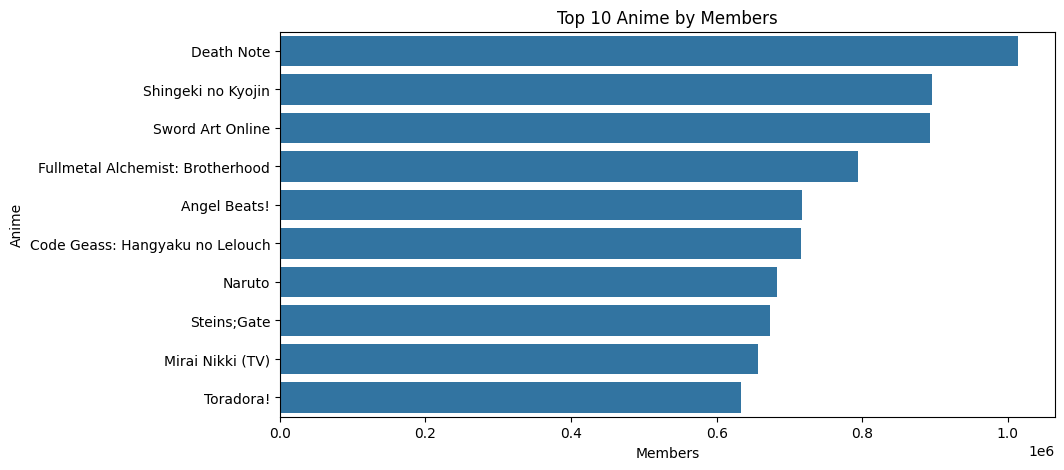

In [15]:
top_members = df.sort_values(by="members", ascending=False).head(10)

display(top_members[["name", "genre", "type", "episodes", "rating", "members"]])

plt.figure(figsize=(10,5))
sns.barplot(data=top_members, x="members", y="name")
plt.title("Top 10 Anime by Members")
plt.xlabel("Members")
plt.ylabel("Anime")
plt.show()

# Feature Extraction

## 14. Decide Features for Similarity

We use the following features:

1. `genre` — important because anime with similar genres are likely to be similar.
2. `type` — TV, Movie, OVA, etc.
3. `episodes` — number of episodes.
4. `rating` — average user rating.
5. `members` — popularity/community size.

Categorical features are converted using one-hot encoding.

Numerical features are normalized using Min-Max Scaling.

In [16]:
feature_df = df[["name", "genre", "type", "episodes", "rating", "members"]].copy()

display(feature_df.head())

,name,genre,type,episodes,rating,members
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


## 15. Genre Feature Processing

In [17]:
# Genre column has comma-separated values, so we create genre dummy variables
genre_dummies = feature_df["genre"].str.get_dummies(sep=", ")

print("Genre dummy shape:", genre_dummies.shape)
display(genre_dummies.head())

Genre dummy shape: (12292, 44)


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 16. Type Encoding

In [18]:
type_dummies = pd.get_dummies(feature_df["type"], prefix="type")

print("Type dummy shape:", type_dummies.shape)
display(type_dummies.head())

Type dummy shape: (12292, 6)


,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,True,False,False,False,False,False
1,False,False,False,False,False,True
2,False,False,False,False,False,True
3,False,False,False,False,False,True
4,False,False,False,False,False,True


## 17. Normalize Numerical Features

In [19]:
numerical_features = feature_df[["episodes", "rating", "members"]]

scaler = MinMaxScaler()
numerical_scaled = scaler.fit_transform(numerical_features)

numerical_scaled_df = pd.DataFrame(
    numerical_scaled,
    columns=["episodes_scaled", "rating_scaled", "members_scaled"]
)

display(numerical_scaled_df.head())

,episodes_scaled,rating_scaled,members_scaled
0,0.000000,0.924370,0.197872
1,0.034673,0.911164,0.782770
2,0.027518,0.909964,0.112689
3,0.012658,0.900360,0.664325
4,0.027518,0.899160,0.149186


## 18. Final Feature Matrix

In [20]:
final_features = pd.concat(
    [
        genre_dummies.reset_index(drop=True),
        type_dummies.reset_index(drop=True),
        numerical_scaled_df.reset_index(drop=True)
    ],
    axis=1
)

print("Final Feature Matrix Shape:", final_features.shape)
display(final_features.head())

Final Feature Matrix Shape: (12292, 53)


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,episodes_scaled,rating_scaled,members_scaled
0,0,0,0,0,0,0,1,0,0,0,...,0,True,False,False,False,False,False,0.000000,0.924370,0.197872
1,1,1,0,0,0,0,1,0,1,0,...,0,False,False,False,False,False,True,0.034673,0.911164,0.782770
2,1,0,0,1,0,0,0,0,0,0,...,0,False,False,False,False,False,True,0.027518,0.909964,0.112689
3,0,0,0,0,0,0,0,0,0,0,...,0,False,False,False,False,False,True,0.012658,0.900360,0.664325
4,1,0,0,1,0,0,0,0,0,0,...,0,False,False,False,False,False,True,0.027518,0.899160,0.149186


# Recommendation System

## 19. Compute Cosine Similarity

Cosine similarity measures how similar two anime are based on their feature vectors.

Value range:

- 1 means highly similar
- 0 means not similar

In [21]:
cosine_sim_matrix = cosine_similarity(final_features)

print("Cosine Similarity Matrix Shape:", cosine_sim_matrix.shape)

Cosine Similarity Matrix Shape: (12292, 12292)


## 20. Create Anime Index Mapping

In [22]:
anime_indices = pd.Series(df.index, index=df["name"]).drop_duplicates()

print("Sample Anime Names:")
print(df["name"].head(10).tolist())

Sample Anime Names:
['Kimi no Na wa.', 'Fullmetal Alchemist: Brotherhood', 'Gintama°', 'Steins;Gate', 'Gintama&#039;', 'Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou', 'Hunter x Hunter (2011)', 'Ginga Eiyuu Densetsu', 'Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare', 'Gintama&#039;: Enchousen']


## 21. Recommendation Function

In [23]:
def recommend_anime(anime_name, top_n=10, similarity_threshold=0.0):
    '''
    Recommend anime based on cosine similarity.

    Parameters:
    anime_name: Name of target anime
    top_n: Number of recommendations
    similarity_threshold: Minimum similarity score required

    Returns:
    DataFrame of recommended anime
    '''

    if anime_name not in anime_indices:
        print("Anime not found in dataset.")
        print("Try one of these names:")
        print(df["name"].head(10).tolist())
        return None

    idx = anime_indices[anime_name]

    # Get similarity scores for target anime
    similarity_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort by similarity score in descending order
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Remove the target anime itself and apply threshold
    filtered_scores = [
        (i, score) for i, score in similarity_scores
        if i != idx and score >= similarity_threshold
    ]

    # Select top N
    top_scores = filtered_scores[:top_n]

    anime_indexes = [i[0] for i in top_scores]
    scores = [i[1] for i in top_scores]

    recommendations = df.iloc[anime_indexes][["anime_id", "name", "genre", "type", "episodes", "rating", "members"]].copy()
    recommendations["similarity_score"] = scores

    return recommendations

## 22. Test Recommendation Function

In [24]:
# You can change the anime name below
target_anime = df["name"].iloc[0]

print("Target Anime:", target_anime)

recommendations = recommend_anime(target_anime, top_n=10, similarity_threshold=0.0)

display(recommendations)

Target Anime: Kimi no Na wa.


,anime_id,name,genre,type,episodes,rating,members,similarity_score
1111,14669,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,1.0,7.67,22599,0.914763
208,28725,Kokoro ga Sakebitagatterunda.,"Drama, Romance, School",Movie,1.0,8.32,59652,0.908175
1494,20903,Harmonie,"Drama, School, Supernatural",Movie,1.0,7.52,29029,0.904473
1959,713,Air Movie,"Drama, Romance, Supernatural",Movie,1.0,7.39,44179,0.904320
60,10408,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,1.0,8.61,197439,0.827330
1199,6408,&quot;Bungaku Shoujo&quot; Movie,"Drama, Mystery, Romance, School",Movie,1.0,7.63,40984,0.819128
2103,1723,Clannad Movie,"Drama, Fantasy, Romance, School",Movie,1.0,7.35,99506,0.818579
11080,33036,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",Movie,1.0,6.57,10668,0.809846
5796,30585,Taifuu no Noruda,"Drama, School, Sci-Fi, Supernatural",Movie,1.0,6.35,14281,0.807914
5805,547,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,3.0,6.35,2043,0.807502


## 23. Recommendation with Different Threshold Values

Threshold values help control recommendation list size.

- Lower threshold gives more recommendations.
- Higher threshold gives fewer but more similar recommendations.

In [25]:
target_anime = df["name"].iloc[0]

thresholds = [0.2, 0.4, 0.6, 0.8]

for threshold in thresholds:
    recs = recommend_anime(target_anime, top_n=10, similarity_threshold=threshold)

    print(f"Threshold: {threshold}")

    if recs is not None:
        print("Number of recommendations returned:", len(recs))
        display(recs[["name", "genre", "type", "rating", "similarity_score"]])

    print("-" * 80)

Threshold: 0.2
Number of recommendations returned: 10


,name,genre,type,rating,similarity_score
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,7.67,0.914763
208,Kokoro ga Sakebitagatterunda.,"Drama, Romance, School",Movie,8.32,0.908175
1494,Harmonie,"Drama, School, Supernatural",Movie,7.52,0.904473
1959,Air Movie,"Drama, Romance, Supernatural",Movie,7.39,0.904320
60,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,8.61,0.827330
1199,&quot;Bungaku Shoujo&quot; Movie,"Drama, Mystery, Romance, School",Movie,7.63,0.819128
2103,Clannad Movie,"Drama, Fantasy, Romance, School",Movie,7.35,0.818579
11080,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",Movie,6.57,0.809846
5796,Taifuu no Noruda,"Drama, School, Sci-Fi, Supernatural",Movie,6.35,0.807914
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,6.35,0.807502


--------------------------------------------------------------------------------
Threshold: 0.4
Number of recommendations returned: 10


,name,genre,type,rating,similarity_score
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,7.67,0.914763
208,Kokoro ga Sakebitagatterunda.,"Drama, Romance, School",Movie,8.32,0.908175
1494,Harmonie,"Drama, School, Supernatural",Movie,7.52,0.904473
1959,Air Movie,"Drama, Romance, Supernatural",Movie,7.39,0.904320
60,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,8.61,0.827330
1199,&quot;Bungaku Shoujo&quot; Movie,"Drama, Mystery, Romance, School",Movie,7.63,0.819128
2103,Clannad Movie,"Drama, Fantasy, Romance, School",Movie,7.35,0.818579
11080,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",Movie,6.57,0.809846
5796,Taifuu no Noruda,"Drama, School, Sci-Fi, Supernatural",Movie,6.35,0.807914
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,6.35,0.807502


--------------------------------------------------------------------------------
Threshold: 0.6
Number of recommendations returned: 10


,name,genre,type,rating,similarity_score
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,7.67,0.914763
208,Kokoro ga Sakebitagatterunda.,"Drama, Romance, School",Movie,8.32,0.908175
1494,Harmonie,"Drama, School, Supernatural",Movie,7.52,0.904473
1959,Air Movie,"Drama, Romance, Supernatural",Movie,7.39,0.904320
60,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,8.61,0.827330
1199,&quot;Bungaku Shoujo&quot; Movie,"Drama, Mystery, Romance, School",Movie,7.63,0.819128
2103,Clannad Movie,"Drama, Fantasy, Romance, School",Movie,7.35,0.818579
11080,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",Movie,6.57,0.809846
5796,Taifuu no Noruda,"Drama, School, Sci-Fi, Supernatural",Movie,6.35,0.807914
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,6.35,0.807502


--------------------------------------------------------------------------------
Threshold: 0.8
Number of recommendations returned: 10


,name,genre,type,rating,similarity_score
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,7.67,0.914763
208,Kokoro ga Sakebitagatterunda.,"Drama, Romance, School",Movie,8.32,0.908175
1494,Harmonie,"Drama, School, Supernatural",Movie,7.52,0.904473
1959,Air Movie,"Drama, Romance, Supernatural",Movie,7.39,0.904320
60,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,8.61,0.827330
1199,&quot;Bungaku Shoujo&quot; Movie,"Drama, Mystery, Romance, School",Movie,7.63,0.819128
2103,Clannad Movie,"Drama, Fantasy, Romance, School",Movie,7.35,0.818579
11080,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",Movie,6.57,0.809846
5796,Taifuu no Noruda,"Drama, School, Sci-Fi, Supernatural",Movie,6.35,0.807914
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,6.35,0.807502


--------------------------------------------------------------------------------


# Evaluation

## 24. Train-Test Split Style Evaluation

Recommendation systems are usually evaluated using user interaction data.  
This dataset does not contain user-anime interaction history, so we create a content-based evaluation approach.

Approach:

1. Split anime into training and testing sets.
2. For each anime in test set, recommend similar anime.
3. Treat anime with at least one common genre as relevant.
4. Calculate precision, recall, and F1-score.

This is a simplified evaluation suitable for this dataset.

In [26]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

Training Data Shape: (9833, 7)
Testing Data Shape: (2459, 7)


## 25. Define Relevance Based on Genre Overlap

In [27]:
def get_genre_set(genre_string):
    if pd.isna(genre_string):
        return set()
    return set([g.strip() for g in str(genre_string).split(",")])

def is_relevant(target_genres, recommended_genres):
    return len(target_genres.intersection(recommended_genres)) > 0

## 26. Evaluation Function for Recommendations

In [28]:
def evaluate_recommendation_system(sample_size=100, top_n=10):
    '''
    Evaluates recommendation system using genre overlap.
    '''

    test_sample = test_df.sample(min(sample_size, len(test_df)), random_state=42)

    precision_list = []
    recall_list = []
    f1_list = []

    for _, row in test_sample.iterrows():
        anime_name = row["name"]
        target_genres = get_genre_set(row["genre"])

        recs = recommend_anime(anime_name, top_n=top_n, similarity_threshold=0.0)

        if recs is None or len(recs) == 0:
            continue

        relevant_flags = []

        for _, rec_row in recs.iterrows():
            recommended_genres = get_genre_set(rec_row["genre"])
            relevant_flags.append(is_relevant(target_genres, recommended_genres))

        relevant_count = sum(relevant_flags)

        # Precision = relevant recommendations / total recommendations
        precision = relevant_count / len(recs)

        # Recall approximation = relevant recommendations / top_n
        # Since actual full relevant set is unknown in this content dataset,
        # we use top_n as approximation.
        recall = relevant_count / top_n

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * (precision * recall) / (precision + recall)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)

    print("Recommendation System Evaluation")
    print("--------------------------------")
    print("Average Precision:", round(avg_precision, 4))
    print("Average Recall   :", round(avg_recall, 4))
    print("Average F1 Score :", round(avg_f1, 4))

    return {
        "Precision": avg_precision,
        "Recall": avg_recall,
        "F1 Score": avg_f1
    }

evaluation_results = evaluate_recommendation_system(sample_size=100, top_n=10)

Recommendation System Evaluation
--------------------------------
Average Precision: 1.0
Average Recall   : 1.0
Average F1 Score : 1.0


## 27. Evaluate with Different Top-N Values

Evaluating for Top-5 Recommendations
Recommendation System Evaluation
--------------------------------
Average Precision: 1.0
Average Recall   : 1.0
Average F1 Score : 1.0
------------------------------------------------------------
Evaluating for Top-10 Recommendations
Recommendation System Evaluation
--------------------------------
Average Precision: 1.0
Average Recall   : 1.0
Average F1 Score : 1.0
------------------------------------------------------------
Evaluating for Top-15 Recommendations
Recommendation System Evaluation
--------------------------------
Average Precision: 0.998
Average Recall   : 0.998
Average F1 Score : 0.998
------------------------------------------------------------
Evaluating for Top-20 Recommendations
Recommendation System Evaluation
--------------------------------
Average Precision: 0.996
Average Recall   : 0.996
Average F1 Score : 0.996
------------------------------------------------------------


,Precision,Recall,F1 Score,Top_N
0,1.000,1.000,1.000,5
1,1.000,1.000,1.000,10
2,0.998,0.998,0.998,15
3,0.996,0.996,0.996,20


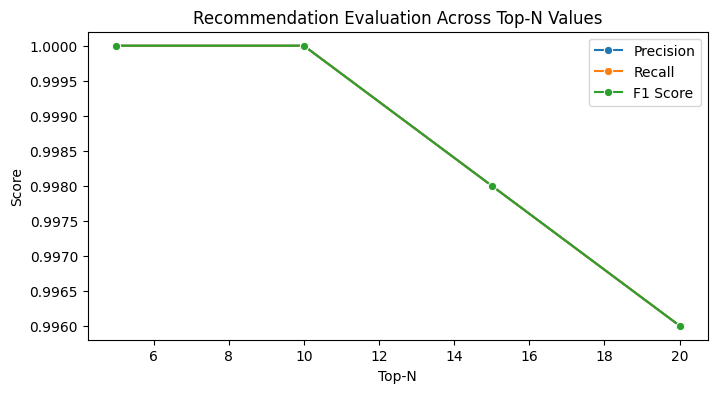

In [29]:
top_n_values = [5, 10, 15, 20]
evaluation_summary = []

for n in top_n_values:
    print(f"Evaluating for Top-{n} Recommendations")
    result = evaluate_recommendation_system(sample_size=100, top_n=n)
    result["Top_N"] = n
    evaluation_summary.append(result)
    print("-" * 60)

evaluation_summary_df = pd.DataFrame(evaluation_summary)
display(evaluation_summary_df)

plt.figure(figsize=(8,4))
sns.lineplot(data=evaluation_summary_df, x="Top_N", y="Precision", marker="o", label="Precision")
sns.lineplot(data=evaluation_summary_df, x="Top_N", y="Recall", marker="o", label="Recall")
sns.lineplot(data=evaluation_summary_df, x="Top_N", y="F1 Score", marker="o", label="F1 Score")
plt.title("Recommendation Evaluation Across Top-N Values")
plt.xlabel("Top-N")
plt.ylabel("Score")
plt.show()

# Analysis of Recommendation System

## 28. Performance Analysis

The recommendation system uses content-based filtering with cosine similarity. It compares anime based on genres, type, episodes, rating, and popularity.

### Strengths
1. Does not require user rating history.
2. Can recommend anime based on item features.
3. Works well when anime metadata is available.
4. Easy to explain because recommendations are based on similarity.

### Limitations
1. It may recommend very similar items only and reduce diversity.
2. It does not learn personal user preferences.
3. If genre information is missing or poor, recommendations may be weak.
4. It cannot capture collaborative patterns such as users with similar taste.

### Areas of Improvement
1. Add user rating data if available.
2. Combine content-based filtering with collaborative filtering.
3. Use weighted features, giving more importance to genre or rating.
4. Use NLP on anime descriptions if descriptions are available.
5. Use hybrid recommendation systems.

# Interview Questions

## Q1. Difference between User-Based and Item-Based Collaborative Filtering

### User-Based Collaborative Filtering
User-based collaborative filtering recommends items based on users with similar preferences.

Example:
If User A and User B both liked many similar anime, then anime liked by User B can be recommended to User A.

### Item-Based Collaborative Filtering
Item-based collaborative filtering recommends items based on similarity between items.

Example:
If many users who liked Anime X also liked Anime Y, then Anime Y can be recommended to someone who liked Anime X.

### Difference

| Point | User-Based Collaborative Filtering | Item-Based Collaborative Filtering |
|---|---|---|
| Similarity calculated between | Users | Items |
| Recommendation logic | Similar users liked this | Similar items are liked together |
| Stability | Less stable because user behavior changes | More stable because item similarity changes slowly |
| Scalability | Can be expensive with many users | Usually more scalable |
| Example | Users like you watched this | Similar anime to this anime |

---

## Q2. What is Collaborative Filtering and How Does It Work?

Collaborative filtering is a recommendation technique that uses user behavior or rating patterns to recommend items.

It works on the idea that:

> Users who agreed in the past are likely to agree again in the future.

### How it works:

1. Collect user-item interaction data.
2. Find similarities between users or items.
3. Predict what a user may like based on similar users or similar items.
4. Recommend the highest-scoring items.

### Types of Collaborative Filtering:

1. User-based collaborative filtering
2. Item-based collaborative filtering
3. Matrix factorization-based collaborative filtering

### Example:
If many users who liked `Naruto` also liked `Bleach`, then a user who likes `Naruto` may get `Bleach` as a recommendation.

# Final Conclusion

In this assignment, an anime recommendation system was implemented using cosine similarity. The dataset was loaded, explored, and cleaned by handling missing values and duplicate anime names.

Feature extraction was performed using genre, anime type, number of episodes, rating, and members. Genre and type were converted into numerical form using dummy encoding, while numerical features were normalized using Min-Max Scaling.

Cosine similarity was used to calculate similarity between anime. A recommendation function was created that accepts an anime name and returns similar anime based on similarity scores. Different threshold values were tested to control the recommendation list size.

A simplified evaluation approach was used because the dataset does not contain user interaction history. Recommendations were evaluated based on genre overlap using precision, recall, and F1-score.

The recommendation system performed as a content-based recommender and can be improved further by adding user rating data, collaborative filtering, or hybrid recommendation techniques.